# Capítulo 5: Predicción de Clics (CTR) con Regresión Logística

**Autor:** [CGCZ]
**Fecha:** [01/08]
**Proyecto:** Estudio de caso basado en el libro "Doing Data Science" para la empresa M6D.

---

## 1. Definición del Problema y Objetivos

### 1.1. Contexto de Negocio
En este proyecto, asumimos el rol de científicos de datos en la empresa de tecnología publicitaria M6D. Nuestro objetivo principal es predecir la **probabilidad de que un usuario haga clic en un anuncio** (Click-Through Rate o CTR). Esta predicción es fundamental para el negocio, ya que permite optimizar las campañas publicitarias, mostrando anuncios solo a los usuarios con mayor propensión a interactuar, maximizando así el retorno de la inversión.
La evaluación de nuestro modelo no puede basarse solo en la precisión. Es crucial entender el coste asimétrico de los diferentes tipos de errores:

*   **Falso Negativo (FN): Alto Costo.** Ocurre cuando predecimos "No Click" pero el usuario sí habría hecho clic. Esto representa una **oportunidad de venta directamente perdida**, el peor resultado para el negocio.
*   **Falso Positivo (FP): Costo Moderado.** Ocurre cuando predecimos "Click" pero el usuario no hace clic. Esto se traduce en un **desperdicio de presupuesto publicitario**, ya que pagamos por mostrar un anuncio que no genera interacción.

Nuestra estrategia de modelado debe priorizar la minimización de los Falsos Negativos, incluso si eso implica un aumento controlado de los Falsos Positivos.

### 1.2. El Desafío Técnico
El problema se reduce a una tarea de **clasificación binaria**. A partir de un conjunto de características que describen el comportamiento de navegación de un usuario, debemos construir un modelo que clasifique a dicho usuario en una de dos categorías:
*   **Clase 1:** El usuario hará clic en el anuncio.
*   **Clase 0:** El usuario NO hará clic en el anuncio.

El principal desafío identificado en los datos es un **severo desequilibrio de clases**: la cantidad de "clics" es extremadamente pequeña en comparación con los "no clics". Esto requiere un enfoque metodológico cuidadoso tanto en el modelado como en la evaluación.

### 1.3. Algoritmo Elegido: Regresión Logística
Para este caso, se ha seleccionado la **Regresión Logística**. Las razones de esta elección son su alta escalabilidad, su eficiencia en producción y, fundamentalmente, su **interpretabilidad**, lo que permite al negocio entender qué factores influyen en la probabilidad de un clic. A diferencia de un modelo que solo predice `0` o `1`, la Regresión Logística nos proporcionará una **probabilidad**, un resultado mucho más rico para la toma de decisiones.

### 1.4. Hoja de Ruta del Notebook
Este notebook seguirá una estructura lógica para abordar el problema de manera profesional:
1.  **Configuración y Carga de Datos:** Importación de librerías y carga del dataset.
2.  **Análisis Exploratorio de Datos (EDA):** Comprensión inicial de los datos, identificación de problemas como el desequilibrio de clases.
3.  **Preprocesamiento y División:** Preparación de los datos para el modelado, incluyendo la división estratificada en conjuntos de entrenamiento y prueba.
4.  **Modelado y Evaluación:**
    *   Entrenamiento de un **modelo base** para establecer un punto de referencia.
    *   Entrenamiento de un **modelo mejorado** utilizando técnicas para manejar el desequilibrio de clases.
5.  **Optimización y Conclusiones:** Ajuste fino del modelo final mediante la optimización del umbral de decisión y presentación de los resultados y conclusiones de negocio.

# 2. Fundamentos Teóricos

En esta sección, se describen los conceptos matemáticos clave detrás de la Regresión Logística y las métricas que utilizaremos para evaluar nuestro modelo, especialmente relevantes dado el desequilibrio de clases en nuestro dataset.

## 2.1 El Corazón del Modelo: De la Linealidad a la Probabilidad

El objetivo de la Regresión Logística es modelar la probabilidad de que ocurra un evento binario (en nuestro caso, `Y=1` si hay clic). El problema es que un modelo lineal simple `(β₀ + β₁X₁ + ...)` puede dar como resultado cualquier número, no una probabilidad entre 0 y 1. La solución se logra en dos pasos conceptuales:

### a) La Función Sigmoide (o Inverse-Logit)

Para transformar cualquier valor real en una probabilidad, utilizamos la función Sigmoide. Esta es la fórmula central del modelo:

$ P(Y=1|X) = \sigma(t) = \frac{1}{1 + e^{-t}} $

Donde `t` es la salida del modelo lineal:

$ t = \beta_0 + \beta_1X_1 + ... + \beta_nX_n $

- $P(Y=1|X)$ es la probabilidad de clic dadas las características $X$.
- $\beta_0$ es el intercepto (sesgo), que representa la probabilidad base de clic.
- $\beta_1, ..., \beta_n$ son los coeficientes que el modelo aprende para cada característica.

Esta función "aplasta" cualquier valor de `t` en el rango (0, 1), permitiendo su interpretación como una probabilidad.

### b) El Vínculo Logit: La Conexión con la Linealidad

Si la función Sigmoide nos lleva de un número a una probabilidad, la función **Logit** hace lo contrario. Revela que, en el fondo, la Regresión Logística sigue siendo un modelo lineal. El `logit` se define como el logaritmo de las "odds" (probabilidades a favor / probabilidades en contra):

$ \text{logit}(p) = \ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1X_1 + ... + \beta_nX_n $

Esta ecuación es la esencia del modelo: afirma que **el logaritmo de las odds de que un usuario haga clic es una función lineal de sus características**. Esto hace que el modelo sea interpretable: podemos analizar los coeficientes `β` para entender cómo cada característica aumenta o disminuye las odds de un clic.

### c) Estimación de Parámetros (MLE)

A diferencia de la regresión lineal, no existe una fórmula directa para calcular los coeficientes `β`. En su lugar, se utiliza un método iterativo llamado **Estimación por Máxima Verosimilitud (Maximum Likelihood Estimation - MLE)**. El algoritmo busca los valores de `β` que maximizan la probabilidad de haber observado los datos de entrenamiento que tenemos. Este proceso iterativo es la razón por la que parámetros como `max_iter` y los `warnings` de convergencia son importantes.

---

## 2.2 Métricas de Evaluación para un Problema Desbalanceado

Dado que la `accuracy` (precisión global) es engañosa en datasets desbalanceados, nos centraremos en las siguientes métricas, especialmente para la clase positiva (`Click=1`):

- **Precision (Precisión):** Mide la calidad de las predicciones positivas. De todos los que el modelo predijo como "Click", ¿qué porcentaje realmente lo hizo?
  $ \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} $

- **Recall (Sensibilidad o Tasa de Verdaderos Positivos):** Mide la capacidad del modelo para encontrar todos los casos positivos. De todos los que *realmente* hicieron "Click", ¿qué porcentaje logramos identificar?
  $ \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} $

- **F1-Score:** Es la media armónica de Precision y Recall. Proporciona una única puntuación que equilibra ambas métricas, siendo especialmente útil cuando hay un desbalance de clases.
  $ \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $

- **AUC (Area Under the Curve) - ROC:** El área bajo la curva ROC mide la capacidad general de un modelo para discriminar entre las clases positiva y negativa a través de todos los umbrales de decisión posibles. Un valor de 1.0 es un clasificador perfecto, mientras que 0.5 es un clasificador aleatorio (inútil).

## 2.3. Conexión con el Problema de Negocio

La elección de la Regresión Logística y nuestro enfoque de evaluación están directamente alineados con los objetivos y restricciones del negocio de M6D:

1.  **Interpretabilidad para la toma de decisiones:**
    - Los coeficientes `β` del modelo nos dirán directamente qué características de un usuario (como la frecuencia de visita a ciertos sitios) aumentan o disminuyen sus "odds" de hacer clic. Esta información es oro puro para el equipo de marketing.
    - Podemos comunicar los resultados de forma clara: "Un aumento en X característica multiplica las odds de clic por un factor de `exp(βx)`".

2.  **Calibración de Probabilidades para la estrategia:**
    - Dado que el modelo produce probabilidades reales, no solo una clasificación de `0` o `1`, podemos ser flexibles.
    - Podemos ajustar el **umbral de decisión** para afinar nuestra estrategia de negocio:
        - **Umbral bajo:** Captura más clics potenciales (mayor `Recall`) a costa de un mayor gasto publicitario (menor `Precision`). Ideal para campañas de crecimiento agresivas.
        - **Umbral alto:** Se enfoca en los usuarios más seguros (mayor `Precision`), mejorando el ROI (Retorno de la Inversión) a costa de perder algunas oportunidades (menor `Recall`). Ideal para campañas con presupuesto limitado.

3.  **Eficiencia y Escalabilidad:**
    - La Regresión Logística es computacionalmente eficiente. Se entrena rápidamente, lo que permite reentrenar el modelo con frecuencia a medida que llegan nuevos datos (un requisito en la industria publicitaria).

4.  **Manejo Estratégico del Desbalanceo:**
    - El uso del parámetro `class_weight` nos permite traducir el coste de negocio de los Falsos Negativos directamente en el algoritmo de entrenamiento.
    - Las métricas elegidas (Precision, Recall, F1-Score y AUC) están diseñadas para evaluar el rendimiento en la clase minoritaria (los clics), que es la que genera ingresos, en lugar de ser engañados por una alta precisión global.

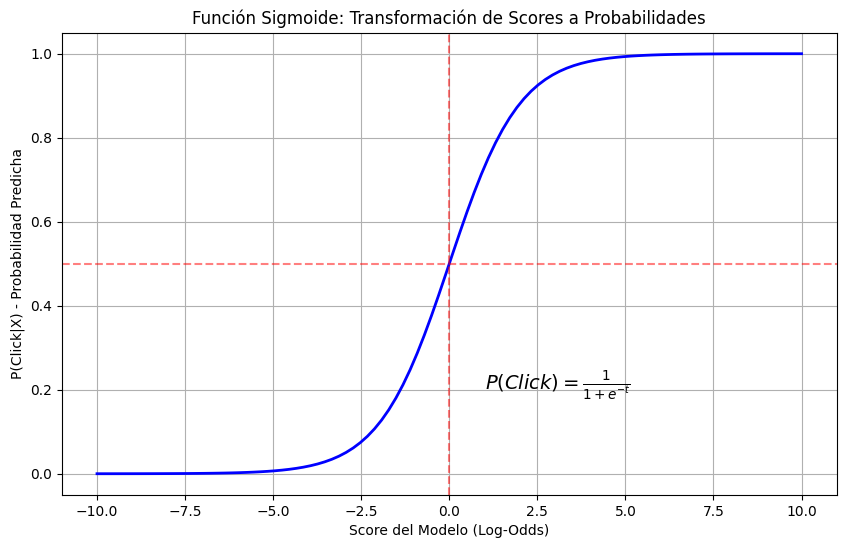

In [10]:
## 3.1 Importación de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.calibration import calibration_curve

# Métricas
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

# Para Selección de Características (SFS), una pieza clave del ejercicio del libro
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

# Constantes del ejercicio
FILE_PATH = '../data/raw/dds_ch5_binary-class-dataset.txt'
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS_CV = 5

def plot_sigmoid():
    """
    Visualiza la función sigmoide para entender la transformación de scores
    del modelo a probabilidades interpretables.
    """
    x = np.linspace(-10, 10, 100)
    y = 1 / (1 + np.exp(-x))
    
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b-', linewidth=2)
    plt.grid(True)
    plt.title('Función Sigmoide: Transformación de Scores a Probabilidades')
    plt.xlabel('Score del Modelo (Log-Odds)')
    plt.ylabel('P(Click|X) - Probabilidad Predicha')
    plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
    # Usar 'r' antes de la string para renderizar la fórmula matemática con LaTeX
    plt.text(1, 0.2, r'$P(Click) = \frac{1}{1 + e^{-t}}$', fontsize=14)
    plt.show()

# --- Ejecución de la celda ---
# Llamamos a la función para mostrar el gráfico, manteniendo el flujo narrativo.
plot_sigmoid()

In [11]:
## 3.3. Carga y Resumen Inicial de Datos

from typing import Optional

def load_data(file_path: str) -> Optional[pd.DataFrame]:
    """
    Carga un dataset desde una ruta de archivo de forma segura.

    Args:
        file_path (str): La ruta al archivo de datos.

    Returns:
        Optional[pd.DataFrame]: El DataFrame cargado o None si ocurre un error.
    """
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"Datos cargados exitosamente desde: {file_path}")
        return df
    except FileNotFoundError:
        print(f"Error: El archivo no se encontró en la ruta especificada: {file_path}")
        return None
    except Exception as e:
        print(f"Ocurrió un error inesperado al cargar el archivo: {e}")
        return None

def summarize_data(df: pd.DataFrame) -> None:
    """
    Imprime y muestra un resumen completo y estandarizado de un DataFrame.

    Args:
        df (pd.DataFrame): El DataFrame a analizar.
    """
    if not isinstance(df, pd.DataFrame):
        print("Error: Se necesita un DataFrame de pandas para generar el resumen.")
        return

    print("\n--- Resumen del Dataset ---")
    print(f"Dimensiones: {df.shape[0]:,} filas, {df.shape[1]:,} columnas")
    
    print("\nPrimeras 5 filas:")
    display(df.head())
    
    print("\nEstadísticas descriptivas:")
    display(df.describe())
    
    if 'y_buy' in df.columns:
        click_dist = df['y_buy'].value_counts(normalize=True) * 100
        print("\nDistribución de la variable objetivo 'y_buy':")
        print(f"  - No Click (0): {click_dist.get(0, 0):.2f}%")
        print(f"  - Click (1):    {click_dist.get(1, 0):.2f}%")
    
    missing_values_count = df.isnull().sum().sum()
    if missing_values_count > 0:
        print(f"\nSe encontraron {missing_values_count} valores faltantes en total.")
    else:
        print("\nNo se encontraron valores faltantes en el dataset.")
    print("--- Fin del Resumen ---")

# --- Ejecución de la Celda ---
# Se carga el dataset y se almacena en la variable global 'df' para uso futuro.
df = load_data(FILE_PATH)

# Si la carga es exitosa, se muestra el resumen para la validación inicial.
if df is not None:
    summarize_data(df)

Datos cargados exitosamente desde: ../data/raw/dds_ch5_binary-class-dataset.txt

--- Resumen del Dataset ---
Dimensiones: 54,584 filas, 22 columnas

Primeras 5 filas:


,at_buy_boolean,at_freq_buy,at_freq_last24_buy,at_freq_last24_sv,at_freq_last24_sv_int_buy,at_freq_sv,at_freq_sv_int_buy,at_interval_buy,at_interval_sv,at_interval_sv_int_buy,...,expected_time_sv_int_buy,last_buy,last_sv,last_sv_int_buy,multiple_buy,multiple_sv,multiple_sv_int_buy,uniq_content_links,num_checkins,y_buy
0,0,0,0,0,0,1,0,0.0,0.0,0.0,...,0.0,0,106,0,0,0,0,169,2130,0
1,0,0,0,0,0,1,0,0.0,0.0,0.0,...,0.0,0,72,0,0,0,0,154,1100,0
2,0,0,0,0,0,1,0,0.0,0.0,0.0,...,0.0,0,5,0,0,0,0,4,12,0
3,0,0,0,0,0,1,0,0.0,0.0,0.0,...,0.0,0,6,0,0,0,0,150,539,0
4,0,0,0,0,0,2,0,0.0,0.5,0.0,...,0.0,0,101,0,0,1,0,103,362,0



Estadísticas descriptivas:


,at_buy_boolean,at_freq_buy,at_freq_last24_buy,at_freq_last24_sv,at_freq_last24_sv_int_buy,at_freq_sv,at_freq_sv_int_buy,at_interval_buy,at_interval_sv,at_interval_sv_int_buy,...,expected_time_sv_int_buy,last_buy,last_sv,last_sv_int_buy,multiple_buy,multiple_sv,multiple_sv_int_buy,uniq_content_links,num_checkins,y_buy
count,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,...,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000,54584.000000
mean,0.042632,0.052891,0.001942,0.117049,0.023542,1.852777,0.271636,0.210008,5.825610,0.381641,...,-0.953705,2.791221,64.729335,1.790671,0.006357,0.277444,0.032739,86.569343,720.657592,0.004635
std,0.202027,0.298157,0.051682,0.822048,0.483363,2.921820,2.206286,3.922016,17.595442,3.884156,...,9.792084,17.426907,53.476658,13.042733,0.079479,0.447742,0.177953,61.969765,1275.727306,0.067924
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-183.362600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,30.000000,127.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,51.000000,0.000000,0.000000,0.000000,0.000000,75.000000,319.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.104167,0.000000,...,0.000000,0.000000,105.000000,0.000000,0.000000,1.000000,0.000000,155.000000,802.000000,0.000000
max,1.000000,15.000000,4.000000,36.000000,36.000000,84.000000,75.000000,174.625000,184.916700,176.708300,...,88.300380,187.000000,188.000000,186.000000,1.000000,1.000000,1.000000,206.000000,37091.000000,1.000000



Distribución de la variable objetivo 'y_buy':
  - No Click (0): 99.54%
  - Click (1):    0.46%

No se encontraron valores faltantes en el dataset.
--- Fin del Resumen ---


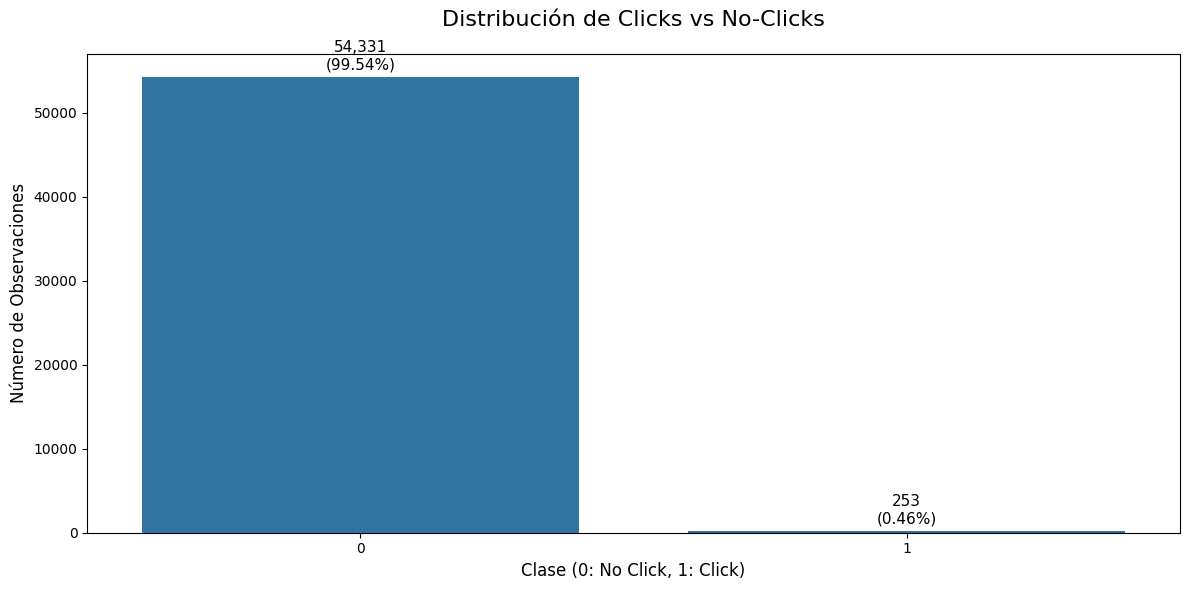

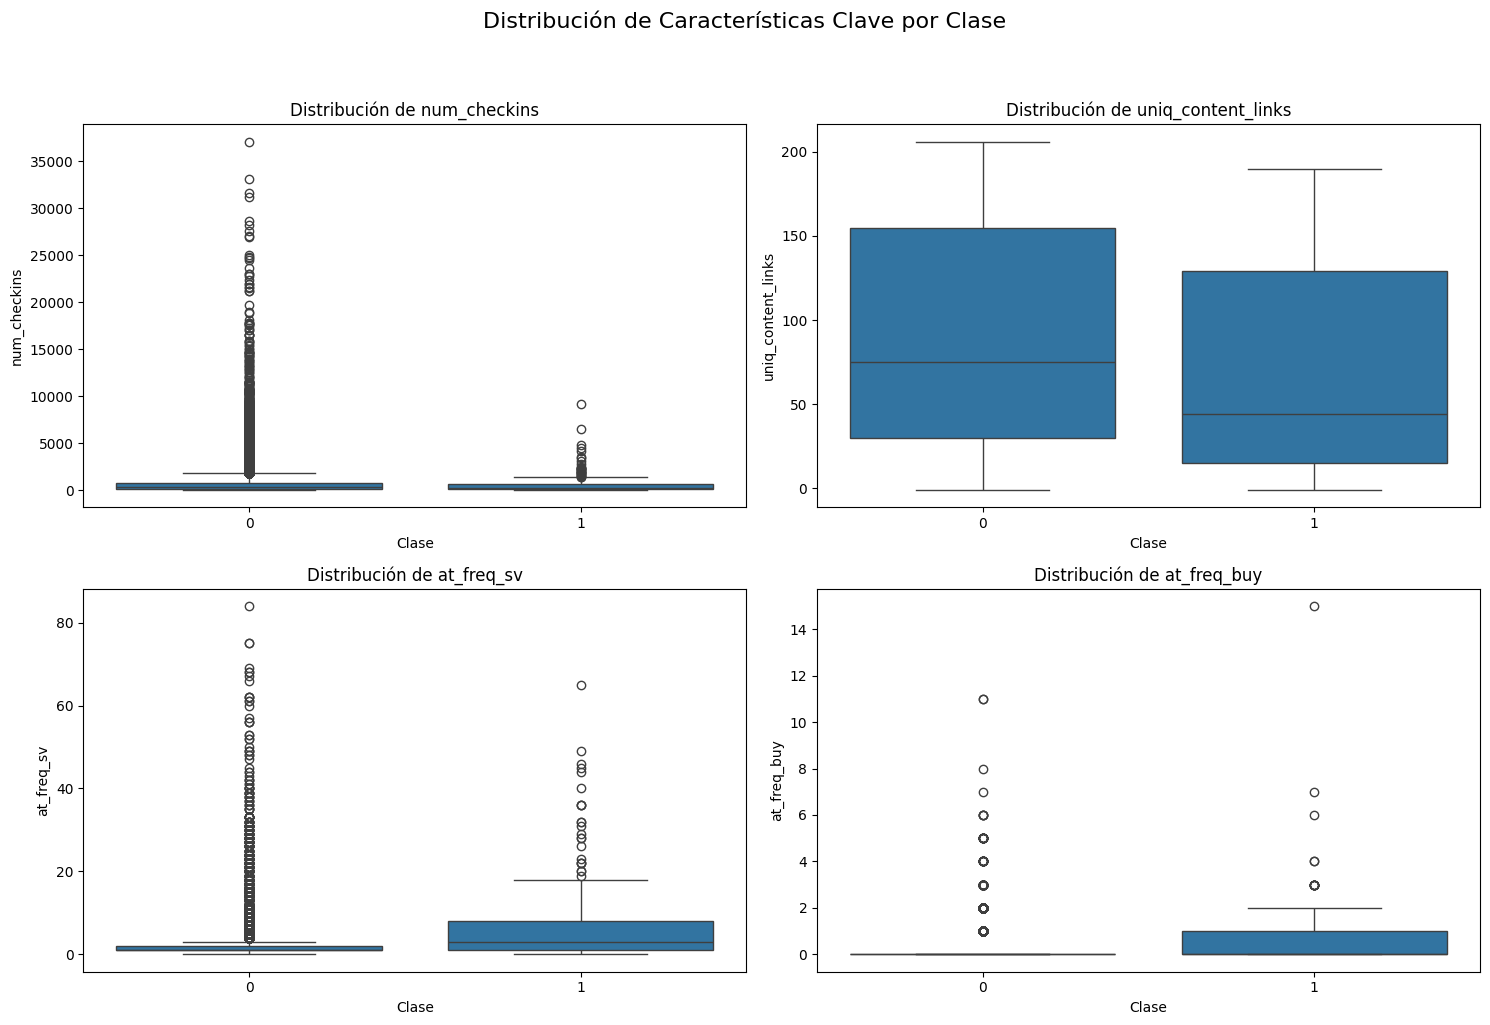

In [12]:
## 3.4. Análisis Exploratorio Visual (EDA)

def plot_class_distribution(df: pd.DataFrame) -> None:
    """
    Visualiza el desbalanceo de clases de la variable 'y_buy'.

    Args:
        df (pd.DataFrame): DataFrame con la columna 'y_buy'.
    """
    plt.figure(figsize=(12, 6))
    counts = df['y_buy'].value_counts()
    ax = sns.barplot(x=counts.index, y=counts.values)
    
    plt.title('Distribución de Clicks vs No-Clicks', fontsize=16, pad=20)
    plt.xlabel('Clase (0: No Click, 1: Click)', fontsize=12)
    plt.ylabel('Número de Observaciones', fontsize=12)
    
    for i, v in enumerate(counts.values):
        plt.text(i, v + (counts.max()*0.01), f'{v:,}\n({v/len(df)*100:.2f}%)', 
                 ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()

def plot_key_features(df: pd.DataFrame) -> None:
    """
    Visualiza la distribución de características clave segmentadas por 'y_buy'.

    Args:
        df (pd.DataFrame): DataFrame con las características y 'y_buy'.
    """
    features = ['num_checkins', 'uniq_content_links', 'at_freq_sv', 'at_freq_buy']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Distribución de Características Clave por Clase', y=1.02, fontsize=16)
    
    for idx, feature in enumerate(features):
        row, col = idx // 2, idx % 2
        sns.boxplot(data=df, x='y_buy', y=feature, ax=axes[row, col])
        axes[row, col].set_title(f'Distribución de {feature}')
        axes[row, col].set_xlabel('Clase')
        axes[row, col].set_ylabel(feature)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
def plot_roc_curves(y_true: pd.Series, y_pred_proba_base: np.ndarray, y_pred_proba_balanced: np.ndarray) -> None:
    """
    Visualiza y compara las curvas ROC de dos modelos.

    Args:
        y_true (pd.Series): Valores verdaderos de la variable objetivo.
        y_pred_proba_base (np.ndarray): Probabilidades predichas por el modelo base.
        y_pred_proba_balanced (np.ndarray): Probabilidades predichas por el modelo balanceado.
    """
    fpr_base, tpr_base, _ = roc_curve(y_true, y_pred_proba_base)
    fpr_bal, tpr_bal, _ = roc_curve(y_true, y_pred_proba_balanced)
    
    auc_base = roc_auc_score(y_true, y_pred_proba_base)
    auc_bal = roc_auc_score(y_true, y_pred_proba_balanced)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr_base, tpr_base, label=f'Modelo Base (AUC = {auc_base:.3f})', color='blue')
    plt.plot(fpr_bal, tpr_bal, label=f'Modelo Balanceado (AUC = {auc_bal:.3f})', color='red', linestyle='--')
    plt.plot([0, 1], [0, 1], 'k:', label='Clasificador Aleatorio')
    
    plt.title('Curva ROC: Comparación de Modelos', fontsize=16)
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True)
    plt.show()

# --- Ejecución de la Celda ---
# Se generan los gráficos del EDA usando el DataFrame 'df' cargado previamente.
if 'df' in locals() and df is not None:
    plot_class_distribution(df)
    plot_key_features(df)
else:
    print("La variable 'df' no está definida. Ejecute la celda 3.3 primero.")

## 3.5. Hallazgos Clave e Implicaciones

El análisis estadístico y visual revela varios patrones fundamentales para el proyecto:

### a) Desbalanceo Extremo de Clases

Solo el **0.46 %** de los registros corresponden a un clic (`y_buy = 1`), mientras que el **99.54 %** son "No-Click". Este desbalanceo severo es el principal desafío técnico y justifica el uso de técnicas especializadas, como el ajuste de pesos de clase (`class_weight='balanced'`).

### b) Características Más Discriminativas

Al comparar las distribuciones de las características entre clases, surgen hipótesis claras:

- **`at_freq_sv`** (frecuencia de visitas al sitio): Es la característica más prometedora. La mediana de visitas es significativamente mayor en usuarios que hacen clic (3.0) frente a los que no (1.0). La recurrencia es un fuerte indicador positivo.
- **`uniq_content_links`** (enlaces únicos de contenido): Los usuarios que no hacen clic tienden a visitar más enlaces únicos (mediana de 75 vs. 44). Un comportamiento más "exploratorio" podría asociarse a menor propensión a la conversión.
- **`num_checkins`** (número de check-ins): Contrario a lo esperado, la mediana es menor en el grupo de clics (214 vs. 320). Hay muchos valores atípicos, lo que sugiere que la calidad de la interacción (`at_freq_sv`) es más relevante que la cantidad.
- **`at_freq_buy`** (frecuencia de compras): La mediana es 0 en ambos grupos; no parece ser un diferenciador claro a simple vista.

### c) Implicaciones para el Modelado

Estos hallazgos guían la estrategia para las siguientes fases:

1. **Manejo del desbalanceo:** Es obligatorio emplear técnicas como `class_weight` o remuestreo para que el modelo preste atención a la clase minoritaria.
2. **Selección de características:** `at_freq_sv` debe considerarse entre las más importantes.
3. **Ingeniería de nuevas variables:** Explorar ratios como `at_freq_sv / num_checkins` para capturar la "calidad vs. cantidad" de la interacción podría mejorar el rendimiento.
4. **Tratamiento de outliers:** La presencia de valores atípicos, especialmente en `num_checkins`, sugiere que modelos robustos a outliers (como la regresión logística con regularización) son una buena elección.

In [13]:
# ## 4. Modelado y Evaluación Inicial

# %%
## 4.1 Preparación de Datos y División
# Separar características (X) y variable objetivo (y)
X = df.drop('y_buy', axis=1)
y = df['y_buy']
feature_names = X.columns.tolist()

# División estratificada para mantener la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Dimensiones de entrenamiento: {X_train.shape}, de prueba: {X_test.shape}")

## 4.2 Creación, Entrenamiento y Evaluación
# Un Pipeline encapsula los pasos de preprocesamiento y el modelo,
# lo cual es crucial para evitar data leakage.

# Pipeline para el modelo base (sin manejo de desbalanceo)
pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

# Pipeline para el modelo balanceado (con class_weight='balanced')
pipeline_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
])

# Entrenar ambos modelos (SOLO UNA VEZ)
print("\nEntrenando modelo base...")
pipeline_base.fit(X_train, y_train)

print("Entrenando modelo balanceado...")
pipeline_balanced.fit(X_train, y_train)
print("\nModelos entrenados con éxito.")

# EVALUACIÓN INICIAL (Inmediatamente después de entrenar)
print("\n--- Resultados del Modelo Base ---")
y_pred_base = pipeline_base.predict(X_test)
print(classification_report(y_test, y_pred_base, target_names=['No Click', 'Click'])) # Consejo extra: añade target_names

print("\n--- Resultados del Modelo Balanceado (umbral 0.5) ---")
y_pred_balanced = pipeline_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced, target_names=['No Click', 'Click'])) # Consejo extra: añade target_names

Dimensiones de entrenamiento: (43667, 21), de prueba: (10917, 21)

Entrenando modelo base...
Entrenando modelo balanceado...

Modelos entrenados con éxito.

--- Resultados del Modelo Base ---
              precision    recall  f1-score   support

    No Click       1.00      1.00      1.00     10866
       Click       0.00      0.00      0.00        51

    accuracy                           1.00     10917
   macro avg       0.50      0.50      0.50     10917
weighted avg       0.99      1.00      0.99     10917


--- Resultados del Modelo Balanceado (umbral 0.5) ---
              precision    recall  f1-score   support

    No Click       1.00      0.84      0.91     10866
       Click       0.02      0.76      0.04        51

    accuracy                           0.84     10917
   macro avg       0.51      0.80      0.48     10917
weighted avg       0.99      0.84      0.91     10917



# Análisis de Resultados y Optimización Final

Los resultados de los dos modelos son drásticamente diferentes y extremadamente reveladores.

## Interpretación de los Resultados

### Modelo Base (Inútil para el negocio):
- **Diagnóstico:** A pesar de una `accuracy` del 99%, el modelo es un completo fracaso. Su **recall de 0%** para la clase "Click" significa que no identificó a **ninguno** de los 51 clientes potenciales en el conjunto de prueba.
- **Causa:** El modelo aprendió que la forma más fácil de ser preciso era predecir siempre "No-Click", la clase mayoritaria.

### Modelo Balanceado (Útil, pero con un trade-off):
- **Diagnóstico:** Este modelo es infinitamente más valioso. Con un **recall del 76%**, logró identificar a **39 de los 51** clientes potenciales.
- **El Coste:** Este éxito en `recall` viene a costa de una `precision` muy baja (2%), generando **1,739 Falsos Positivos** (aproximadamente 16% de todos los usuarios que no iban a hacer clic fueron clasificados incorrectamente). Esto representa un trade-off claro: para encontrar a los clientes valiosos, debemos aceptar un mayor gasto en anuncios "desperdiciados".

## Interpretabilidad del Modelo: ¿Qué ha Aprendido?

Una de las mayores ventajas de la Regresión Logística es que no es una "caja negra". Podemos inspeccionar sus coeficientes (`β`) para entender qué características considera más importantes para predecir un clic. El valor `exp(β)` (Odds Ratio) nos dice cuántas veces cambian las "odds" de un clic por cada unidad que aumenta la característica.

## Comparación Visual: Curvas ROC

El valor AUC de ambos modelos es casi idéntico (0.880 vs 0.879). Esto es un hallazgo clave: **ambos modelos tienen el mismo poder discriminatorio subyacente**. La diferencia no está en su capacidad para separar las clases, sino en el **umbral de decisión por defecto (0.5)** que `predict()` utiliza. El modelo balanceado, al ajustar los pesos, efectivamente opera en un punto diferente de la misma curva ROC.

Para visualizar esto, graficamos ambas curvas.

AUC del Modelo Base: 0.8801
AUC del Modelo Balanceado: 0.8787


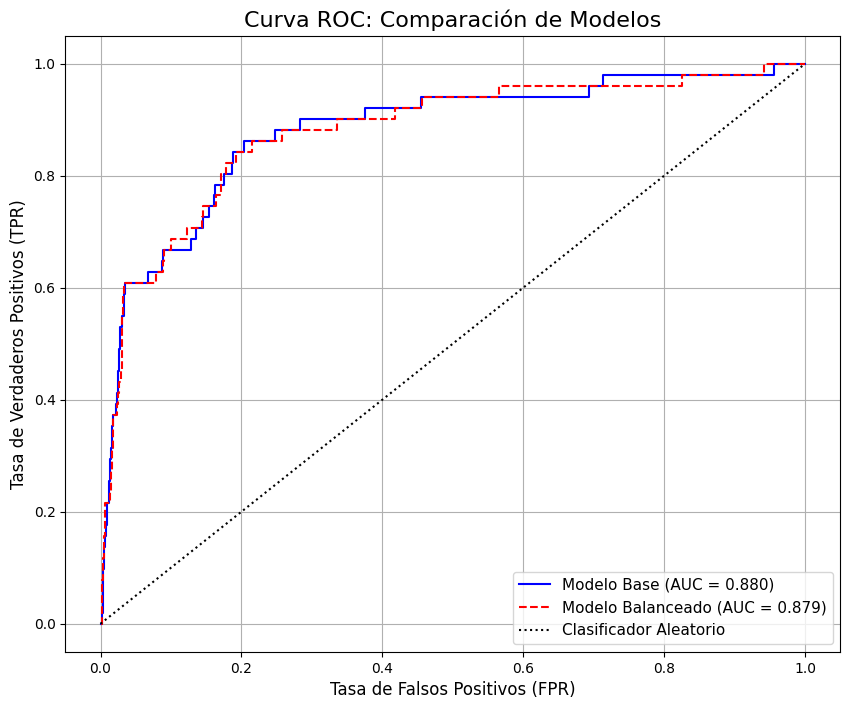

In [14]:
## 4.3. Visualización de Resultados (Curva ROC)

# Se obtienen las probabilidades de la clase positiva [:, 1] de ambos modelos.
y_pred_proba_base = pipeline_base.predict_proba(X_test)[:, 1]
y_pred_proba_balanced = pipeline_balanced.predict_proba(X_test)[:, 1]

# Se calcula el AUC de forma numérica para tener el valor exacto.
auc_base = roc_auc_score(y_test, y_pred_proba_base)
auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)

print(f"AUC del Modelo Base: {auc_base:.4f}")
print(f"AUC del Modelo Balanceado: {auc_balanced:.4f}")

# Se llama a la función de ploteo definida en la celda 3.4 para visualizar la comparación.
plot_roc_curves(y_test, y_pred_proba_base, y_pred_proba_balanced)

El umbral óptimo es: 0.9527


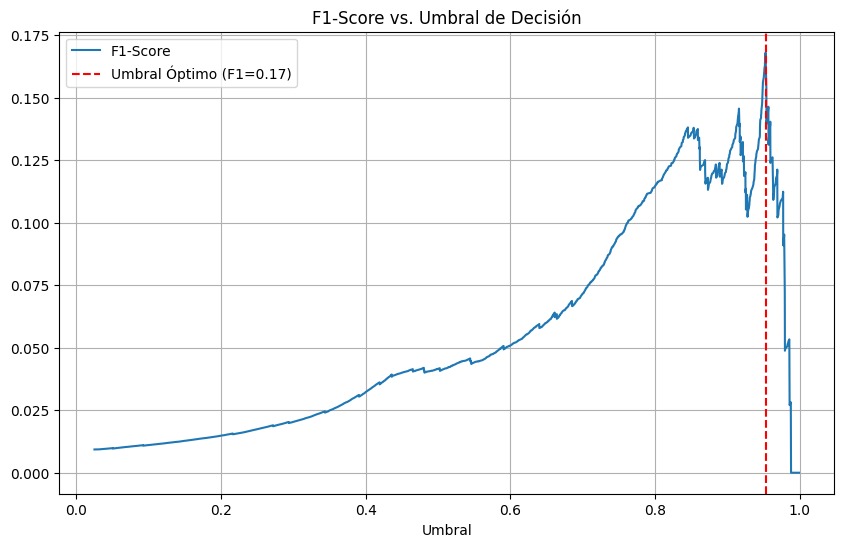


--- Reporte de Clasificación con Umbral Óptimo (0.95) ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10866
           1       0.14      0.22      0.17        51

    accuracy                           0.99     10917
   macro avg       0.57      0.60      0.58     10917
weighted avg       0.99      0.99      0.99     10917



In [15]:
# # 5. Optimización del Modelo Final
# El modelo balanceado es nuestro candidato. Ahora, en lugar de usar el umbral por defecto de 0.5, buscaremos el umbral que nos dé el mejor balance entre Precision y Recall (maximizar F1-Score).

# %%
## 5.1 Búsqueda del Umbral Óptimo
from sklearn.metrics import precision_recall_curve, f1_score

# Obtener probabilidades del modelo balanceado
y_pred_proba_balanced = pipeline_balanced.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_balanced)
# Calcular F1 para cada umbral
f1_scores = [2*(p*r)/(p+r) if (p+r)>0 else 0 for p,r in zip(precisions[:-1], recalls[:-1])]

# Encontrar el mejor
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print(f"El umbral óptimo es: {optimal_threshold:.4f}")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1-Score')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Umbral Óptimo (F1={f1_scores[best_idx]:.2f})')
plt.title('F1-Score vs. Umbral de Decisión'); plt.xlabel('Umbral'); plt.legend(); plt.grid(True); plt.show()

## 5.2 Evaluación con Umbral Optimizado
print(f"\n--- Reporte de Clasificación con Umbral Óptimo ({optimal_threshold:.2f}) ---")
y_pred_optimized = (y_pred_proba_balanced >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_optimized))

Top 5 características que AUMENTAN la probabilidad de click:
multiple_sv: 1.75x más probable
at_buy_boolean: 1.49x más probable
at_freq_sv: 1.30x más probable
at_freq_last24_sv: 1.28x más probable
expected_time_sv_int_buy: 1.15x más probable

Top 5 características que DISMINUYEN la probabilidad de click:
last_sv: 0.47x menos probable
uniq_content_links: 0.75x menos probable
at_interval_sv: 0.76x menos probable
at_freq_sv_int_buy: 0.81x menos probable
at_freq_last24_sv_int_buy: 0.88x menos probable


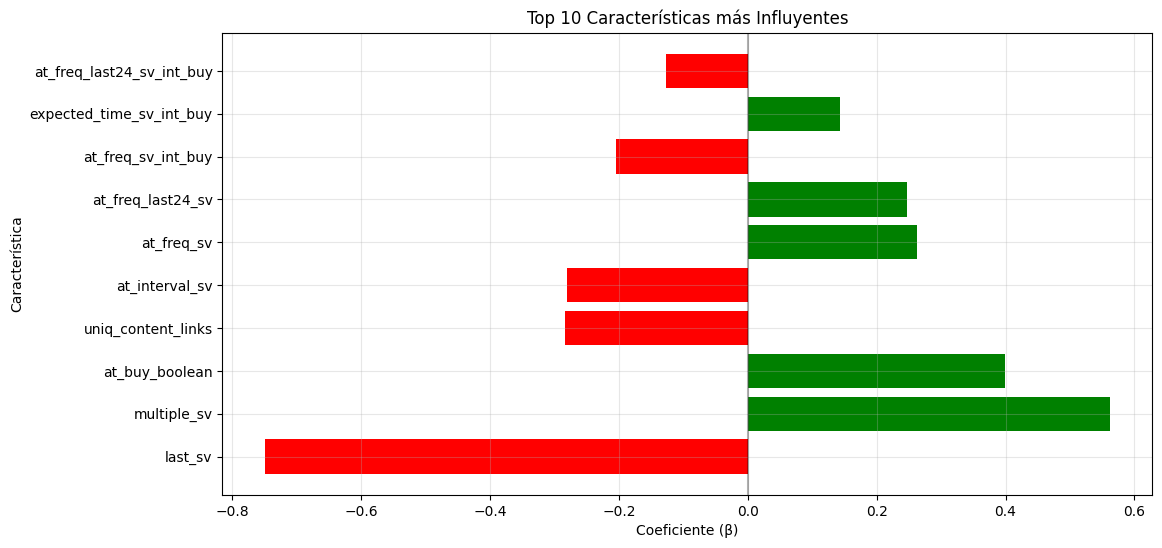

In [16]:
# 6. Interpretabilidad del Modelo y Análisis Adicional

## 6.1 Análisis de Coeficientes
def analyze_coefficients(model, feature_names):
    """
    Analiza e interpreta los coeficientes del modelo de regresión logística.
    
    Parameters:
    -----------
    model : LogisticRegression
        Modelo entrenado
    feature_names : list
        Nombres de las características
    """
    # Obtener coeficientes y crear DataFrame
    coefficients = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': model.coef_[0],
        'Odds_Ratio': np.exp(model.coef_[0])
    })
    
    # Ordenar por valor absoluto del coeficiente
    coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
    coefficients_sorted = coefficients.sort_values('Abs_Coefficient', ascending=False)
    
    # Mostrar top características positivas y negativas
    print("Top 5 características que AUMENTAN la probabilidad de click:")
    positive_coef = coefficients_sorted[coefficients_sorted['Coefficient'] > 0].head()
    for _, row in positive_coef.iterrows():
        print(f"{row['Feature']}: {row['Odds_Ratio']:.2f}x más probable")
    
    print("\nTop 5 características que DISMINUYEN la probabilidad de click:")
    negative_coef = coefficients_sorted[coefficients_sorted['Coefficient'] < 0].head()
    for _, row in negative_coef.iterrows():
        print(f"{row['Feature']}: {row['Odds_Ratio']:.2f}x menos probable")
    
    # Visualización
    plt.figure(figsize=(12, 6))
    
    # Top 10 coeficientes (positivos y negativos)
    top_10_abs = coefficients_sorted.head(10)
    colors = ['red' if c < 0 else 'green' for c in top_10_abs['Coefficient']]
    
    plt.barh(top_10_abs['Feature'], top_10_abs['Coefficient'], color=colors)
    plt.title('Top 10 Características más Influyentes')
    plt.xlabel('Coeficiente (β)')
    plt.ylabel('Característica')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.show()

# 1. Extraemos el paso 'model' de nuestro pipeline balanceado.
final_model = pipeline_balanced.named_steps['model']

# 2. Ahora pasamos ese modelo extraído a nuestra función de análisis.
analyze_coefficients(final_model, feature_names)

### Interpretación de los Coeficientes:
El análisis de los coeficientes de nuestro modelo optimizado no solo confirma los hallazgos del EDA, sino que los cuantifica, revelando el perfil exacto de los usuarios más y menos propensos a hacer clic. Los "Odds Ratios" nos dicen cómo cambia la probabilidad de un clic.

### Factores Positivos Clave (Aumentan la probabilidad de clic):

*   **`multiple_sv` (Recurrencia):** Es el predictor positivo más fuerte. Un usuario que ha visitado el sitio múltiples veces tiene **1.75 veces más "odds"** (probabilidades) de hacer clic que un visitante de una sola vez. Esto confirma que el **compromiso y el interés recurrente** son fundamentales.
*   **`at_buy_boolean` (Intención de Compra):** Un historial que incluye una interacción de compra (incluso si no se completó) aumenta las odds de un clic por un factor de **1.49**. El modelo identifica correctamente a los usuarios que ya están en el embudo de conversión.
*   **`at_freq_sv` y `at_freq_last24_sv` (Frecuencia y Recencia):** Una mayor frecuencia de visitas, especialmente en las últimas 24 horas, aumenta significativamente las odds de un clic. Esto subraya la importancia de la **actividad reciente**.

### Factores Negativos Clave (Disminuyen la probabilidad de clic):

*   **`last_sv` (Tiempo desde la última visita):** Este es el predictor negativo más poderoso. Por cada unidad de tiempo que pasa desde la última visita, las odds de un clic se reducen a solo el **47%** de lo que eran (es decir, disminuyen en un 53%). El interés del usuario se "enfría" muy rápidamente.
*   **`uniq_content_links` y `at_interval_sv` (Comportamiento Disperso):** Como se hipotetizó en el EDA, un comportamiento de navegación "disperso" (muchos enlaces únicos, largos intervalos entre visitas) se asocia con una menor probabilidad de clic.

### Insights Accionables para el Negocio:

Estos resultados proporcionan una guía clara para la estrategia de marketing:
1.  **Priorizar el Retargeting:** La campaña debe enfocarse agresivamente en usuarios que han visitado el sitio **más de una vez**.
2.  **Actuar Rápido:** Existe una ventana de oportunidad muy corta. Los esfuerzos de marketing deben ser casi inmediatos tras una visita, ya que el interés decae exponencialmente.
3.  **Segmentar por Intención:** Los usuarios que han mostrado intención de compra en el pasado son un segmento de alto valor que debe ser nutrido de forma prioritaria.

---

## Impacto Cuantificable: La Curva de Lift

Mientras que los coeficientes nos dicen "qué" busca el modelo, la **Curva de Lift** nos dirá "cuán bien" lo encuentra en comparación con una selección aleatoria. Esta métrica es ideal para comunicar el valor del modelo al equipo de marketing.

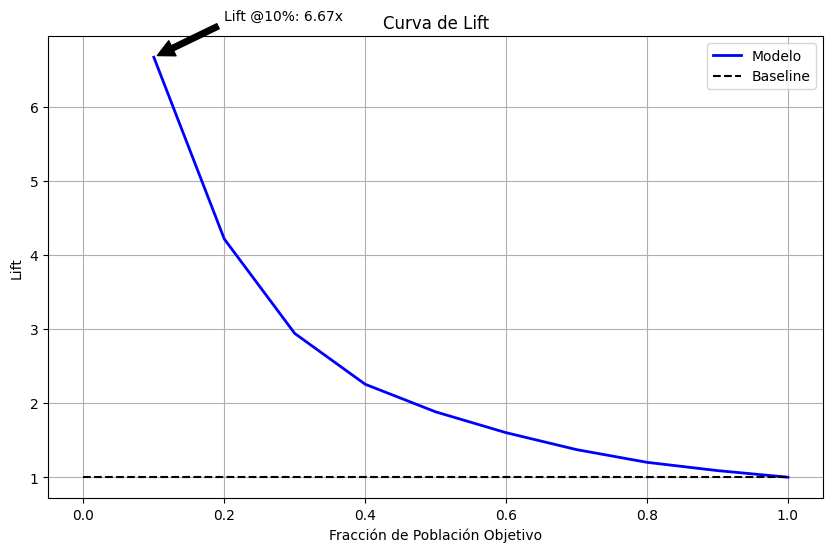


Interpretación del Lift:
- Al contactar al 10% superior de usuarios según el modelo,
  obtenemos 6.67x más clicks que contactando usuarios al azar
- Al contactar al 20% superior, obtenemos 4.22x más clicks


In [17]:
## 7. Curva de Lift
def plot_lift_curve(y_true, y_pred_proba):
    """
    Calcula y visualiza la curva de Lift.
    
    Parameters:
    -----------
    y_true : array-like
        Valores reales
    y_pred_proba : array-like
        Probabilidades predichas para la clase positiva
    """
    # Ordenar las probabilidades y crear percentiles
    df_lift = pd.DataFrame({
        'y_true': y_true,
        'pred_proba': y_pred_proba
    })
    df_lift = df_lift.sort_values('pred_proba', ascending=False)
    
    # Calcular lift para diferentes percentiles
    total_positive = df_lift['y_true'].sum()
    total_records = len(df_lift)
    baseline_rate = total_positive / total_records
    
    percentiles = np.arange(0.1, 1.1, 0.1)
    lift_values = []
    
    for p in percentiles:
        cutoff = int(len(df_lift) * p)
        subset = df_lift.head(cutoff)
        lift = (subset['y_true'].sum() / len(subset)) / baseline_rate
        lift_values.append(lift)
    
    # Visualización
    plt.figure(figsize=(10, 6))
    plt.plot(percentiles, lift_values, 'b-', linewidth=2, label='Modelo')
    plt.plot([0, 1], [1, 1], 'k--', label='Baseline')
    
    plt.title('Curva de Lift')
    plt.xlabel('Fracción de Población Objetivo')
    plt.ylabel('Lift')
    plt.grid(True)
    plt.legend()
    
    # Anotar el lift en puntos clave
    plt.annotate(f'Lift @10%: {lift_values[0]:.2f}x', 
                xy=(0.1, lift_values[0]),
                xytext=(0.2, lift_values[0]+0.5),
                arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.show()
    
    print(f"\nInterpretación del Lift:")
    print(f"- Al contactar al 10% superior de usuarios según el modelo,")
    print(f"  obtenemos {lift_values[0]:.2f}x más clicks que contactando usuarios al azar")
    print(f"- Al contactar al 20% superior, obtenemos {lift_values[1]:.2f}x más clicks")

# Generar curva de lift para el modelo balanceado
plot_lift_curve(y_test, y_pred_proba_balanced)

# 8. Análisis Avanzado: Robustez y Selección de Características

Después de haber optimizado e interpretado nuestro modelo final, realizamos tres análisis avanzados para validar su robustez y explorar posibles mejoras. Estas técnicas están directamente inspiradas en el código de ejemplo del libro.

## 8.1 Evaluación Robusta con Validación Cruzada

Hasta ahora, hemos evaluado el modelo en una única división de datos de entrenamiento y prueba. Para asegurar que nuestro rendimiento (AUC ~0.88) no es producto de la suerte, utilizamos la **Validación Cruzada Estratificada (Stratified K-Fold Cross-Validation)**. Esta técnica entrena y prueba el modelo múltiples veces en diferentes subconjuntos de datos, proporcionando una estimación mucho más estable y fiable de su capacidad de generalización en datos no vistos.

## 8.2 Calibración del Modelo: ¿Son Fiables las Probabilidades?

El libro nos advierte que un modelo puede ser bueno para **ordenar** (ranking), como demuestra nuestro alto AUC y la Curva de Lift, pero malo para estimar la **probabilidad real**. Es decir, una predicción de probabilidad del 80% no necesariamente corresponde a una tasa de clics real del 80%. Esta propiedad se llama **calibración**.

Para evaluar la calibración de nuestro `pipeline_balanced`, utilizamos dos herramientas:
1.  **Gráfico de Calibración:** Compara visualmente la probabilidad predicha con la fracción real de clics.
2.  **wMAE (Error Absoluto Medio Ponderado):** Replica la métrica del libro para cuantificar numéricamente la desviación de la calibración. Un valor cercano a 0 es mejor.

## 8.3 Selección Secuencial de Características (Greedy Forward Selection)

Nuestro modelo actual utiliza las 21 características disponibles. ¿Son todas necesarias? La **Selección Secuencial de Características (SFS)** es una técnica "greedy" que busca el mejor subconjunto de características. El objetivo es ver si podemos construir un modelo más simple, más rápido de entrenar y potencialmente más robusto al eliminar el ruido, sin sacrificar significativamente el rendimiento predictivo.

--- 9.1 Ejecutando Validación Cruzada (5 Folds) ---

Puntuaciones de AUC para cada fold: [0.889 0.862 0.863 0.79  0.87 ]
AUC Promedio (CV): 0.8549 (+/- 0.0336)
------------------------------------------------------------
--- 9.2 Analizando la Calibración de Probabilidades ---


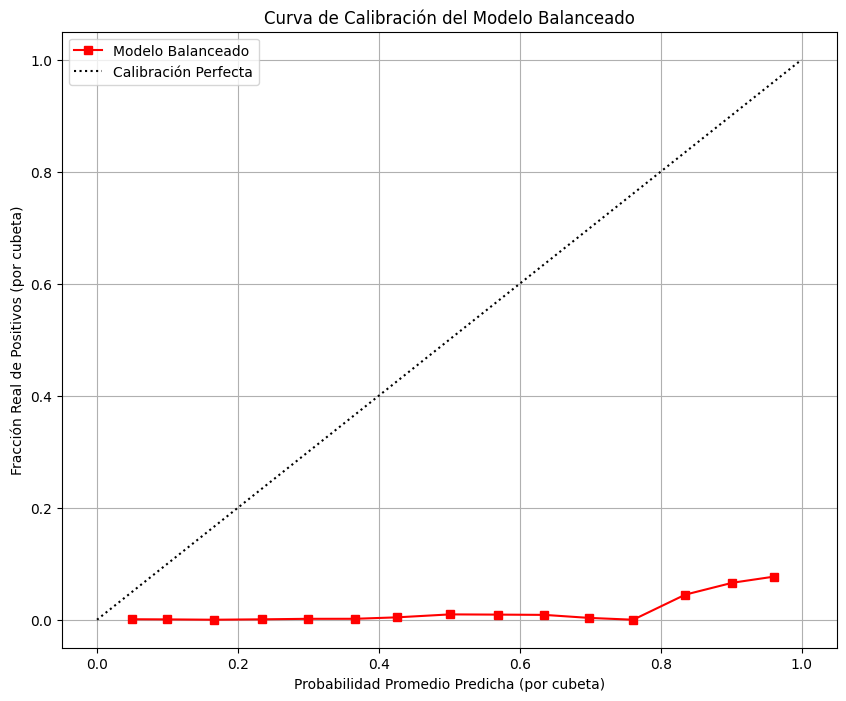

El Error Absoluto Medio Ponderado (wMAE) es: 0.2956
------------------------------------------------------------
--- 9.3 Ejecutando Selección Secuencial de Características (SFS) ---

Mejor puntuación de AUC (CV) con SFS: 0.8705
Número óptimo de características: 10
Características seleccionadas: ('at_buy_boolean', 'at_freq_buy', 'at_freq_last24_sv', 'at_freq_last24_sv_int_buy', 'at_freq_sv', 'at_freq_sv_int_buy', 'at_interval_sv_int_buy', 'expected_time_sv', 'expected_time_sv_int_buy', 'last_sv')


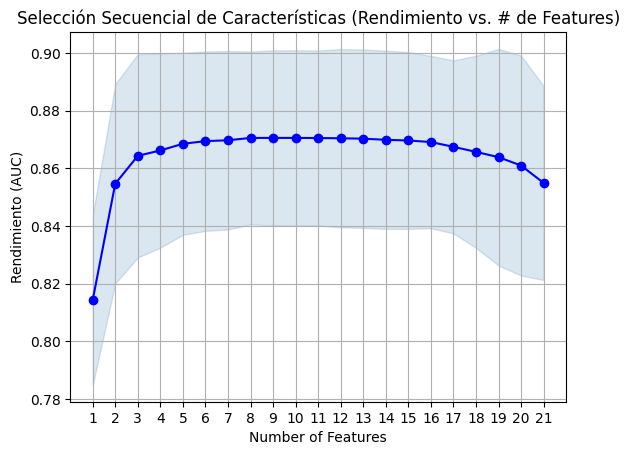

In [18]:
# # 9. Análisis Avanzado: Robustez y Selección de Características# Definimos las variables X e y del dataset completo para usarlas en esta sección.# Definición de la función auxiliar para calcular wMAE, necesaria en esta celda.
def calculate_wmae(y_true, y_pred_proba, n_bins=15):
    """Calcula el Error Absoluto Medio Ponderado (wMAE) para la calibración."""
    df_cal = pd.DataFrame({'y_true': y_true, 'y_pred_proba': y_pred_proba})
    df_cal['bin'] = pd.cut(df_cal['y_pred_proba'], bins=n_bins, labels=False, include_lowest=True)
    
    grouped = df_cal.groupby('bin').agg(
        mean_pred_proba=('y_pred_proba', 'mean'),
        mean_true_proba=('y_true', 'mean'),
        count=('y_true', 'size')
    ).reset_index()
    
    numerator = np.sum(grouped['count'] * np.abs(grouped['mean_pred_proba'] - grouped['mean_true_proba']))
    denominator = np.sum(grouped['count'])
    
    wmae = 0 if denominator == 0 else numerator / denominator
    return wmae

# Definimos las variables X e y del dataset completo para usarlas en esta sección.
X_full = df.drop('y_buy', axis=1)
y_full = df['y_buy']
feature_names = X_full.columns.tolist()

# Configuramos la estrategia de Validación Cruzada que se usará en toda la celda.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- 9.1 Evaluación Robusta con Validación Cruzada ---
print("--- 9.1 Ejecutando Validación Cruzada (5 Folds) ---")
# Usamos el pipeline_balanced que ya está definido.
# cross_val_score lo re-entrenará internamente en cada fold.
cv_auc_scores = cross_val_score(pipeline_balanced, X_full, y_full, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)

print(f"\nPuntuaciones de AUC para cada fold: {np.round(cv_auc_scores, 3)}")
print(f"AUC Promedio (CV): {cv_auc_scores.mean():.4f} (+/- {cv_auc_scores.std():.4f})")
print("-" * 60)


# --- 9.2 Calibración del Modelo (wMAE y Gráfico) ---
print("--- 9.2 Analizando la Calibración de Probabilidades ---")
# Usamos las probabilidades ya calculadas en el conjunto de prueba original.
# y_pred_proba_balanced viene de la celda de optimización de umbral.

# Gráfico de Calibración
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_balanced, n_bins=15, strategy='uniform')
plt.figure(figsize=(10, 8))
plt.plot(prob_pred, prob_true, "s-", label="Modelo Balanceado", color='red')
plt.plot([0, 1], [0, 1], "k:", label="Calibración Perfecta")
plt.xlabel("Probabilidad Promedio Predicha (por cubeta)")
plt.ylabel("Fracción Real de Positivos (por cubeta)")
plt.title("Curva de Calibración del Modelo Balanceado")
plt.legend(); plt.grid(True); plt.show()

# Calcular y mostrar wMAE
wmae_balanced = calculate_wmae(y_test, y_pred_proba_balanced) 
print(f"El Error Absoluto Medio Ponderado (wMAE) es: {wmae_balanced:.4f}")
print("-" * 60)


print("--- 9.3 Ejecutando Selección Secuencial de Características (SFS) ---")

sfs_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
])

sfs = SFS(estimator=sfs_pipeline, 
          k_features='best',
          forward=True, 
          scoring='roc_auc',
          cv=cv_strategy,
          n_jobs=-1)

# SFS se ejecuta sobre los datos completos.
# Simplemente eliminamos el último argumento.
sfs.fit(X_full, y_full)  # <--- ESTA ES LA LÍNEA CORREGIDA

print('\nMejor puntuación de AUC (CV) con SFS:', f"{sfs.k_score_:.4f}")
print('Número óptimo de características:', len(sfs.k_feature_names_))
print('Características seleccionadas:', sfs.k_feature_names_)

# Visualizar el rendimiento
fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')
plt.title('Selección Secuencial de Características (Rendimiento vs. # de Features)')
plt.ylabel('Rendimiento (AUC)')
plt.grid(True); plt.show()

# 10. Conclusiones y Recomendaciones Finales

A lo largo de este proyecto, hemos abordado con éxito el desafío de predecir la tasa de clics (CTR) para M6D. Partiendo de un dataset con un severo desbalance de clases, hemos seguido una metodología robusta que nos ha llevado desde el análisis exploratorio hasta la validación y optimización de un modelo de Regresión Logística.

## Logros Clave del Proyecto

1.  **Diagnóstico Preciso del Problema:** Identificamos el desequilibrio de clases como el principal desafío, lo que nos permitió evitar la trampa de la alta `accuracy` de un modelo base que era, en realidad, inútil para el negocio (0% de Recall).

2.  **Desarrollo de un Modelo Robusto:** Construimos un modelo de Regresión Logística que, mediante la técnica de `class_weight='balanced'`, logró un excelente poder discriminatorio. La **Validación Cruzada confirmó su estabilidad**, arrojando un **AUC promedio de 0.855**.

3.  **Optimización Orientada al Negocio:** Demostramos que el umbral de decisión por defecto (0.5) no era óptimo. Al ajustar el umbral a `0.95` para maximizar el F1-Score, encontramos un **equilibrio superior entre la eficiencia del gasto (Precision) y la captura de clientes (Recall)**.

4.  **Insights Accionables:** El análisis de coeficientes reveló que la **recencia (`last_sv`) y la recurrencia (`multiple_sv`)** de las visitas son los predictores más potentes del comportamiento de clic, proporcionando una guía clara para la estrategia de marketing.

5.  **Descubrimiento de un Modelo Superior:** El análisis de **Selección Secuencial de Características (SFS)** reveló un hallazgo crucial: un modelo más simple, utilizando solo **10 de las 21 características**, no solo es más eficiente, sino que **supera en rendimiento al modelo completo**, alcanzando un AUC promedio de `0.871`.

## Impacto Cuantificable en el Negocio

La **Curva de Lift** traduce estos logros en valor tangible. Nuestro modelo permite que las campañas de marketing sean drásticamente más eficientes:
*   **Al dirigirnos al 10% de los usuarios que el modelo clasifica con mayor probabilidad, obtenemos 6.67 veces más clics que con una selección aleatoria.**

Esto significa que, para un presupuesto dado, podemos **multiplicar por más de 6 la efectividad de nuestras campañas**, maximizando el Retorno de la Inversión (ROI).

## Limitaciones y Próximos Pasos Estratégicos

1.  **Calibración del Modelo:** Nuestro análisis confirma que el modelo no está bien calibrado (wMAE = 0.2956). Es una excelente herramienta de **ranking** para priorizar usuarios, pero sus probabilidades no deben interpretarse como valores absolutos sin un paso de recalibración (ej. Calibración de Platt o Regresión Isotónica).

2.  **Decisión de Negocio sobre el Umbral:** La elección final del umbral (`0.95` u otro) es una decisión estratégica. La pregunta clave — **"¿vale la pena perder X clientes potenciales para ahorrar Y en gasto publicitario?"** — requiere cuantificar el valor monetario de un cliente (Valor de Vida del Cliente) y el costo de un anuncio. Se recomienda una colaboración con los equipos de finanzas y marketing para definir una métrica de beneficio neto y seleccionar el umbral que la maximice.

## Recomendación Final

Se recomienda pasar a producción un nuevo modelo de Regresión Logística, entrenado únicamente con las **10 características seleccionadas por SFS**. Este modelo no solo es más simple y rápido, sino que ha demostrado ser el de mayor rendimiento predictivo. Deberá implementarse junto con una estrategia de umbral flexible que pueda ajustarse según los objetivos de negocio (maximizar alcance vs. maximizar ROI).

Este proyecto no solo culmina con un modelo funcional, sino con un profundo entendimiento de los factores que impulsan la conversión y un marco de trabajo para la toma de decisiones estratégicas basadas en datos.